# 04 Whisper 共享编码器情感分类训练
复用 Whisper Encoder 作为特征提取器，冻结编码器参数，只训练分类头。

**使用前**：将整个项目上传到运行环境，或通过 Git clone。

In [1]:
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q openai-whisper noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/identifier


In [2]:
import sys
import time
import copy
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset, random_split
import whisper
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config, LABEL2ID, EMOTION_LABELS
from models.whisper_emotion import WhisperEmotionHead

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

设备: cuda
GPU: NVIDIA GeForce RTX 4090


## 1. 准备数据集

In [3]:
class WhisperMelDataset(Dataset):
    """直接加载音频，使用 Whisper 的 log_mel_spectrogram 生成输入。"""
    def __init__(self, processed_dir):
        self.samples = []
        for label_name in sorted(os.listdir(processed_dir)):
            label_dir = os.path.join(processed_dir, label_name)
            if not os.path.isdir(label_dir) or label_name not in LABEL2ID:
                continue
            label_id = LABEL2ID[label_name]
            for wav_path in sorted(glob.glob(os.path.join(label_dir, '*.wav'))):
                self.samples.append((wav_path, label_id))
        print(f'WhisperMelDataset: {len(self.samples)} 个样本')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        audio = whisper.load_audio(path)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio)
        return mel, label


processed_dir = cfg['paths']['processed_data']
all_datasets = []
for subset in ('ravdess', 'casia'):
    d = os.path.join(processed_dir, subset)
    if os.path.isdir(d):
        all_datasets.append(WhisperMelDataset(d))

full_dataset = ConcatDataset(all_datasets)
total = len(full_dataset)
train_n = int(total * cfg['training']['train_ratio'])
val_n = int(total * cfg['training']['val_ratio'])
test_n = total - train_n - val_n

gen = torch.Generator().manual_seed(cfg['training']['seed'])
train_set, val_set, test_set = random_split(full_dataset, [train_n, val_n, test_n], generator=gen)

bs = min(cfg['training']['batch_size'], 16)
train_loader = DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

print(f'训练: {train_n}, 验证: {val_n}, 测试: {test_n}')

WhisperMelDataset: 1440 个样本
训练: 1152, 验证: 144, 测试: 144


## 2. 构建模型

In [4]:
whisper_size = cfg['model']['whisper_size']
print(f'加载 Whisper {whisper_size} 模型...')
whisper_model = whisper.load_model(whisper_size, device=device)

model = WhisperEmotionHead(
    whisper_model, num_classes=cfg['emotion']['num_classes'], freeze_encoder=True,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'参数: 总计={total_params:,}, 可训练={trainable:,}')

加载 Whisper small 模型...
参数: 总计=87,215,814, 可训练=213,702


## 3. 训练

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg['training']['learning_rate'],
    weight_decay=cfg['training']['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5,
)

epochs = cfg['training']['epochs']
patience = cfg['training']['patience']
best_val_loss = float('inf')
best_cls_state = None
wait = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    t0 = time.time()
    
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for mels, labels in train_loader:
        mels, labels = mels.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(mels)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * mels.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total += mels.size(0)
    
    model.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for mels, labels in val_loader:
            mels, labels = mels.to(device), labels.to(device)
            logits = model(mels)
            loss = criterion(logits, labels)
            vl_loss += loss.item() * mels.size(0)
            vl_correct += (logits.argmax(1) == labels).sum().item()
            vl_total += mels.size(0)
    
    tr_loss /= tr_total; tr_acc = tr_correct / tr_total
    vl_loss /= vl_total; vl_acc = vl_correct / vl_total
    scheduler.step(vl_loss)
    elapsed = time.time() - t0
    
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    
    print(f'Epoch {epoch:3d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | {elapsed:.1f}s')
    
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_cls_state = copy.deepcopy(model.classifier.state_dict())
        wait = 0
        print(f'  -> 最佳模型已保存')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 连续 {patience} 轮无改善')
            break

# 保存
os.makedirs(cfg['paths']['checkpoints'], exist_ok=True)
torch.save({
    'classifier_state': best_cls_state,
    'whisper_size': whisper_size,
    'num_classes': cfg['emotion']['num_classes'],
}, cfg['paths']['best_shared_model'])
np.savez(os.path.join(cfg['paths']['checkpoints'], 'shared_history.npz'), **history)
print(f'模型已保存至: {cfg["paths"]["best_shared_model"]}')

Epoch   1/100 | Train Loss: 1.7663 Acc: 0.2604 | Val Loss: 1.7265 Acc: 0.2500 | 70.2s
  -> 最佳模型已保存
Epoch   2/100 | Train Loss: 1.7067 Acc: 0.3160 | Val Loss: 1.6229 Acc: 0.3958 | 71.6s
  -> 最佳模型已保存
Epoch   3/100 | Train Loss: 1.5392 Acc: 0.4010 | Val Loss: 1.3785 Acc: 0.4444 | 69.4s
  -> 最佳模型已保存
Epoch   4/100 | Train Loss: 1.4424 Acc: 0.4253 | Val Loss: 1.3601 Acc: 0.4028 | 69.9s
  -> 最佳模型已保存
Epoch   5/100 | Train Loss: 1.4214 Acc: 0.4193 | Val Loss: 1.2999 Acc: 0.4375 | 69.1s
  -> 最佳模型已保存
Epoch   6/100 | Train Loss: 1.3507 Acc: 0.4436 | Val Loss: 1.2257 Acc: 0.4444 | 69.2s
  -> 最佳模型已保存
Epoch   7/100 | Train Loss: 1.3140 Acc: 0.4609 | Val Loss: 1.2042 Acc: 0.5069 | 69.0s
  -> 最佳模型已保存
Epoch   8/100 | Train Loss: 1.2515 Acc: 0.4983 | Val Loss: 1.1348 Acc: 0.5486 | 69.4s
  -> 最佳模型已保存
Epoch   9/100 | Train Loss: 1.2498 Acc: 0.5061 | Val Loss: 1.1742 Acc: 0.5208 | 70.5s
Epoch  10/100 | Train Loss: 1.2045 Acc: 0.5252 | Val Loss: 1.0769 Acc: 0.5833 | 69.7s
  -> 最佳模型已保存
Epoch  11/100 | Train L

## 4. 训练曲线

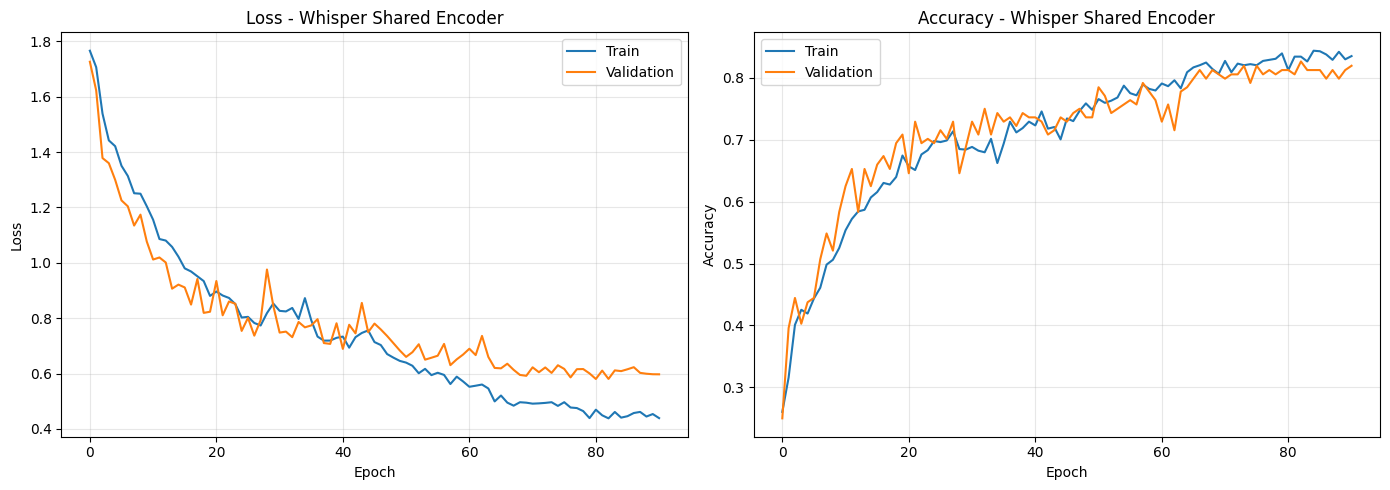

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss - Whisper Shared Encoder')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy - Whisper Shared Encoder')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'shared_training_curves.png'), dpi=150)
plt.show()

## 5. 测试集评估

              precision    recall  f1-score   support

       happy       0.67      0.71      0.69        14
       angry       1.00      0.95      0.98        21
         sad       0.65      0.72      0.68        18
     neutral       0.91      0.97      0.94        33
        fear       0.95      0.79      0.86        24
    surprise       0.88      0.88      0.88        34

    accuracy                           0.86       144
   macro avg       0.84      0.84      0.84       144
weighted avg       0.87      0.86      0.86       144



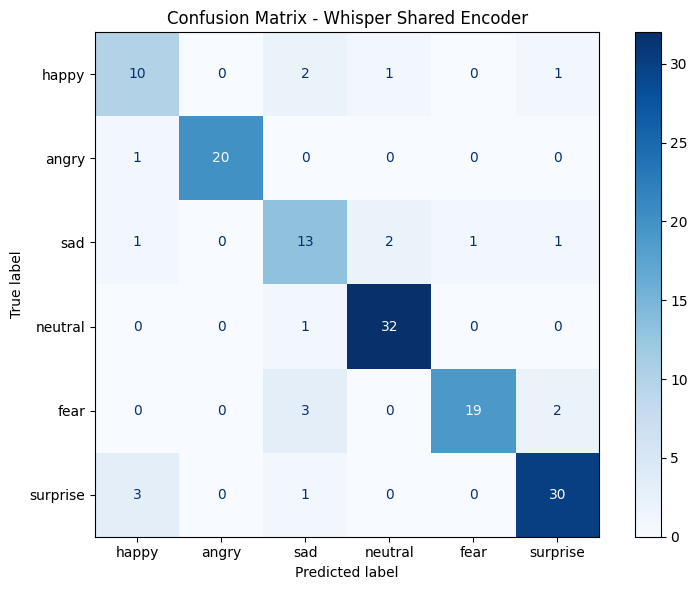

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.classifier.load_state_dict(best_cls_state)
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for mels, labels in test_loader:
        mels = mels.to(device)
        preds = model(mels).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels.numpy())

print(classification_report(all_labels_list, all_preds, target_names=EMOTION_LABELS))

cm = confusion_matrix(all_labels_list, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Whisper Shared Encoder')
plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'shared_confusion_matrix.png'), dpi=150)
plt.show()

## 6. 对比两个模型
如果之前已经训练过 CNN+BiLSTM+Attention 模型，可以加载对比。

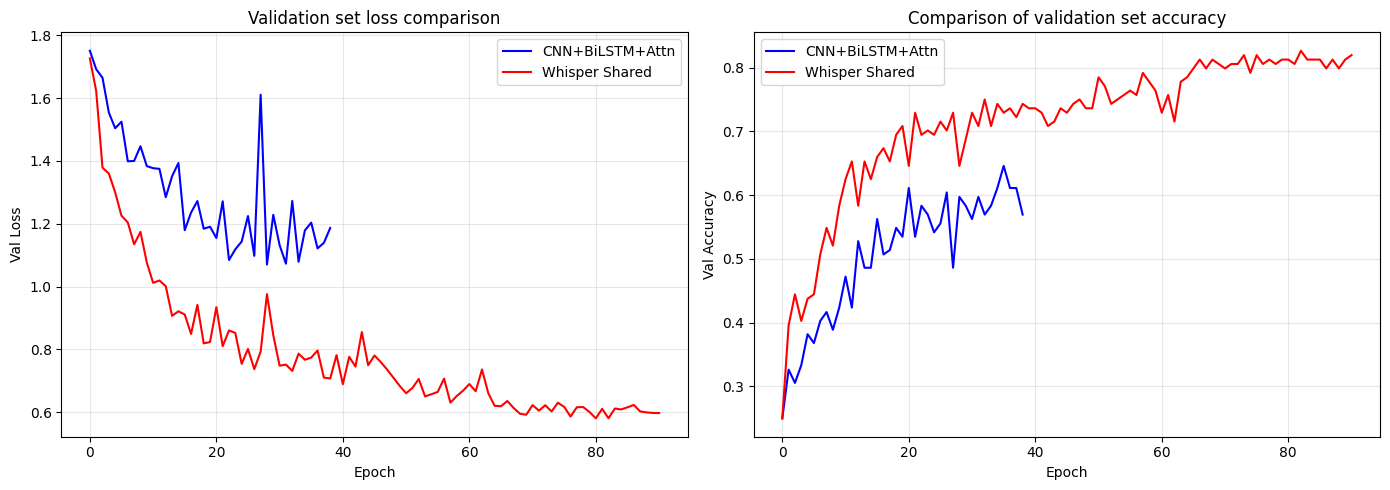

In [9]:
emotion_hist_path = os.path.join(cfg['paths']['checkpoints'], 'emotion_history.npz')
shared_hist_path = os.path.join(cfg['paths']['checkpoints'], 'shared_history.npz')

if os.path.isfile(emotion_hist_path) and os.path.isfile(shared_hist_path):
    eh = np.load(emotion_hist_path)
    sh = np.load(shared_hist_path)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(eh['val_loss'], label='CNN+BiLSTM+Attn', color='blue')
    ax1.plot(sh['val_loss'], label='Whisper Shared', color='red')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
    ax1.set_title('Validation set loss comparison')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    
    ax2.plot(eh['val_acc'], label='CNN+BiLSTM+Attn', color='blue')
    ax2.plot(sh['val_acc'], label='Whisper Shared', color='red')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
    ax2.set_title('Comparison of validation set accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(cfg['paths']['checkpoints'], 'model_comparison.png'), dpi=150)
    plt.show()
else:
    print('缺少其中一个模型的训练历史，跳过对比。')